In [14]:
import yfinance as yf # 匯入 yfinance 套件，用來抓取 Yahoo Finance 的股票資料
import pandas as pd # 匯入 pandas 套件，用來處理表格資料 (DataFrame)
import matplotlib.pyplot as plt # 匯入 matplotlib 的 pyplot，用來畫圖
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'sans-serif'] # 設定畫圖時使用的字型為微軟正黑體，避免中文顯示亂碼

In [ ]:
symbols = [
    '0050.TW',   # 台灣50
    '00631L.TW', # 元大台灣50正2
    '0056.TW',   # 元大高股息
    '00929.TW',  # 復華台灣科技優息
    '00878.TW',  # 國泰永續高股息
    'QQQ',       # Invesco QQQ (美股 ETF)
    'TQQQ'       # ProShares UltraPro QQQ (美股 ETF)
]

data_s = [] # 建立一個空列表，用來存放抓下來的資料
for symbol in symbols:
    # 使用 yfinance 下載資料，從 2015-01-01 開始
    data = yf.download(symbol, start='2015-01-01')
    # 將抓下來的資料加入 data_s 列表
    data_s.append(data)
data_total = pd.concat(data_s, axis=1) # 將列表中的資料合併成一個大的 DataFrame，axis=1 表示左右合併 (依欄位)

In [ ]:
ret = data_total['Close'].pct_change() # 計算每日報酬率 (pct_change 會計算 (今天-昨天)/昨天)，只取 'Close' (收盤價)
(ret+1).cumprod().plot() # 計算累積報酬率並畫圖。cumprod() 是累積相乘，plot() 是畫圖

In [ ]:
ret_ = ret.dropna() # 移除有缺失值 (NaN) 的資料
(ret_+1).cumprod().plot() # 再次畫出累積報酬率圖

In [ ]:
day_of_year = 242 # 假設一年有 242 個交易日
ret_yearly = ret.mean() * day_of_year # 計算年化報酬率 (平均每日報酬 * 交易日數)
print(f'年化報酬')
print(ret_yearly)

std_yearly = ret.std() * (day_of_year ** 0.5) # 計算年化風險 (標準差 * 交易日數的平方根)
print(f'年化風險')
print(std_yearly)


In [ ]:

sharp_yearly = ret_yearly / std_yearly # 計算夏普比率 (年化報酬 / 年化風險)
print(f'年化夏普比率')
print(sharp_yearly)

bad_std_yearly = ret[ret<0].std() * (day_of_year ** 0.5) # 計算下檔風險 (只考慮報酬率小於 0 的部分的標準差)
sortino_yearly = ret_yearly /bad_std_yearly # 計算索提諾比率 (年化報酬 / 下檔風險)
print(f'年化所提諾比率')
print(sortino_yearly)

In [ ]:
mdd = ( (ret+1).cumprod() / (ret+1).cumprod().cummax() -1 ).min() # 計算最大回檔 (MDD)
mdd

In [ ]:
newhigh = ((ret+1).cumprod() / (ret+1).cumprod().cummax()) == 1 # 判斷每一天是否創新高
newhigh[ret.isna()] = None # 將報酬率為 NaN 的日子的創新高判斷設為 None
new_high = newhigh.mean() # 計算創新高天數的比例
print(f'new_high')
print(new_high)

In [ ]:
kpi_s = [] # 建立一個列表來收集各項 KPI 指標
kpi_s.append(ret_yearly)
kpi_s.append(std_yearly)
kpi_s.append(sharp_yearly)
kpi_s.append(sortino_yearly)
kpi_s.append(mdd)
kpi_s.append(new_high)
kpi_table = pd.concat(kpi_s, axis=1) # 將列表合併成一個 DataFrame
kpi_table.columns = ['年化報酬','年化風險','夏普比例','所提諾比率','最大回檔','創高率'] # 設定欄位名稱
kpi_table.transpose().plot.bar() # 轉置表格並畫出長條圖
# kpi_table.plot.bar()

In [ ]:
from FinMind.data import DataLoader # 匯入 FinMind 的 DataLoader
api = DataLoader()
df = api.taiwan_stock_info() # 抓取台灣股票資訊

In [ ]:
print(df) # 印出抓取到的股票資訊

In [ ]:
symbols = df[
    (df['industry_category']=='ETF') & # 篩選產業類別是 'ETF'
    (df['stock_id'].str.contains('009')) & # 篩選股票代號包含 '009'
    (df['stock_name'].str.contains('高息')) # 篩選股票名稱包含 '高息'
    ]
print(symbols)

In [ ]:
symbols = [ f"{i}.TW" for i in symbols['stock_id'].tolist() ] # 將篩選出的股票代號加上 '.TW'

In [ ]:
[i * 2 for i in range(100)] # 列表推導式範例：產生 0 到 99 的數字，並將每個數字乘以 2

In [ ]:
[ f"{i}*{j}={i*j}" for i in range(2,10) for j in range(1,10)] # 列表推導式範例：九九乘法表

In [ ]:
symbols = [ f"{i}.TW" for i in symbols['stock_id'].tolist() ] # (重複) 將股票代號加上 .TW
data_s = []
for symbol in symbols:
    data = yf.download(symbol, start='2015-01-01') # 下載資料
    data_s.append(data)
data_total = pd.concat(data_s, axis=1) # 合併資料
ret = data_total['Close'].pct_change() # 計算報酬率
newhigh[ret.isna()] = None # 處理 NaN

In [ ]:
symbols = df[
    (df['industry_category'] == 'ETF') &
    (df['stock_id'].str.contains('0050')) |
    (df['stock_id'].str.contains('0056'))
]
symbols2 = [ f"{i}.TW" for i in symbols['stock_id'].tolist() ]
stock_performance(symbols2)

In [12]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import random

user_agents = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/141.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/141.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:129.0) Gecko/20100101 Firefox/129.0",
]

headers = { 
    "User-Agent": random.choice(user_agents)
}

url = "https://finance.yahoo.com/markets/world-indices/"

response = requests.get(url , headers=headers)
# soup = BeautifulSoup(response.content, 'html.parser')
# print(soup.prettify())

tables = pd.read_html(response.text)
tables[0]  


C:\Users\fordi\AppData\Local\Temp\ipykernel_4044\605729640.py:22: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Symbol,Name,Unnamed: 2,Price,Change,Change %,Volume,Day Range,52 Wk Range
0,^GSPC,S&P 500,NaN,"6,812.61 +46.73 (+0.69%)",46.73,+0.69%,2.725B,"6,783.87 6,831.44","4,835.04 6,920.34"
1,^DJI,Dow Jones Industrial Average,NaN,"47,427.12 +314.67 (+0.67%)",314.67,+0.67%,458.137M,"47,196.15 47,571.40","36,611.78 48,431.57"
2,^IXIC,NASDAQ Composite,NaN,"23,214.69 +189.10 (+0.82%)",189.10,+0.82%,6.377B,"23,074.39 23,280.58","14,784.03 24,019.99"
3,^NYA,NYSE Composite Index,NaN,"21,713.13 +161.39 (+0.75%)",161.39,+0.75%,0,0.00 0.00,"0.00 21,876.99"
4,^XAX,NYSE American Composite Index,NaN,"7,404.12 +103.15 (+1.41%)",103.15,+1.41%,0,0.00 0.00,"0.00 7,464.69"
5,^BUK100P,Cboe UK 100,NaN,969.35 -0.41 (-0.04%),-0.41,-0.04%,0,966.81 970.86,751.90 991.30
6,^RUT,Russell 2000 Index,NaN,"2,486.12 +20.14 (+0.82%)",20.14,+0.82%,0,"2,464.71 2,502.96","1,732.99 2,541.67"
7,^VIX,CBOE Volatility Index,NaN,17.16 -0.03 (-0.17%),-0.03,-0.17%,0,17.05 17.22,12.70 60.13
8,^FTSE,FTSE 100,NaN,"9,681.70 -9.88 (-0.10%)",-9.88,-0.10%,0,"9,658.86 9,699.82","7,544.80 9,930.10"
9,^GDAXI,DAX P,NaN,"23,792.88 +66.66 (+0.28%)",66.66,+0.28%,0,"23,708.42 23,830.97","18,489.91 24,771.34"


C:\Users\fordi\AppData\Local\Temp\ipykernel_4044\3208309178.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\fordi\AppData\Local\Temp\ipykernel_4044\3208309178.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\fordi\AppData\Local\Temp\ipykernel_4044\3208309178.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\fordi\AppData\Local\Temp\ipykernel_4044\3208309178.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01')
[********************

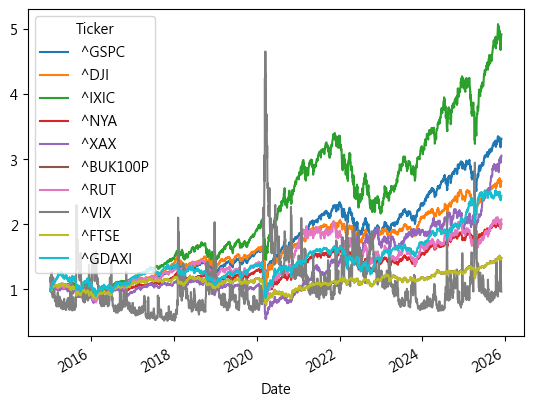

C:\Users\fordi\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


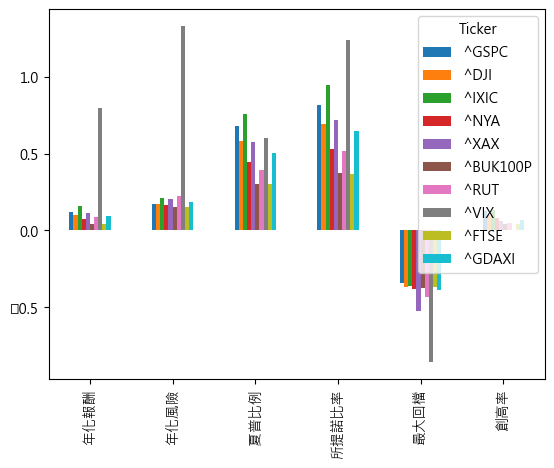

In [15]:
tab = tables[0]
symbols_w = tab['Symbol'].dropna().tolist()[:10]
stock_performance(symbols_w)

In [ ]:
# 定期定額回測邏輯
inv_time = 0 # 投資次數計數器 (或是天數計數器)
once_amount = 5000 # 每次定期定額投入的金額
total_shares = 0 # 累積持有的股數
total_cost = 0 # 累積投入的總成本
portfolio_value = [] # 記錄每一天的投資組合總市值
cost_history = [] # 記錄每一天的累積成本 (方便畫圖比較)

# 假設我們要回測的是列表中的第一個股票 (例如 0050.TW)
# 這裡我們先用 data_total 中的第一檔股票來做示範
# 注意：data_total 是多層索引 (MultiIndex)，我們取第一層的第一個 symbol
target_symbol = symbols[0] 
print(f'開始回測標的: {target_symbol}')

# 取得該股票的收盤價資料
target_data = data_total['Close'][target_symbol]

for date, price in target_data.items():
    # 排除股價為 NaN 的情況 (可能還沒上市或當天沒交易)
    if pd.isna(price):
        portfolio_value.append(0)
        cost_history.append(0)
        continue

    # 策略：每 20 個交易日 (約一個月) 買入一次
    if inv_time % 20 == 0:
        shares_bought = once_amount / price # 計算當次能買到的股數
        total_shares += shares_bought # 累積股數
        total_cost += once_amount # 累積成本
        # print(f'日期: {date.date()}, 買入股價: {price:.2f}, 買入股數: {shares_bought:.2f}, 累積成本: {total_cost}')

    # 計算當天市值 = 累積股數 * 當天股價
    current_value = total_shares * price
    portfolio_value.append(current_value)
    cost_history.append(total_cost)
    
    inv_time += 1

# 將結果畫出來
plt.figure(figsize=(12, 6))
plt.plot(target_data.index, portfolio_value, label='定期定額總市值')
plt.plot(target_data.index, cost_history, label='累積投入成本', linestyle='--')
plt.title(f'{target_symbol} 定期定額回測 (每次 {once_amount} 元)')
plt.xlabel('日期')
plt.ylabel('金額')
plt.legend()
plt.grid(True)
plt.show()